In [ ]:
# Load YOLOv8 face detection model
# For offline use, download yolov8n.pt first
FACE_MODEL_PATH = "yolov8n.pt"  # Change to your model path

if os.path.exists(FACE_MODEL_PATH):
    face_model = YOLO(FACE_MODEL_PATH)
    print("Face detection model loaded")
else:
    print(f"Warning: {FACE_MODEL_PATH} not found. Downloading...")
    face_model = YOLO('yolov8n.pt')  # Downloads automatically
    print("Face detection model downloaded and loaded")


Using script: detect_face.py


In [ ]:
def detect_and_crop_faces(image_path, model, conf_threshold=0.25):
    """
    Detect faces in image and return cropped faces
    
    Args:
        image_path: Path to image
        model: YOLOv8 model
        conf_threshold: Confidence threshold
    
    Returns:
        List of cropped face images (PIL Images)
        List of bounding boxes [(x1, y1, x2, y2), ...]
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return [], []
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Detect faces (class 0 = person in COCO)
    results = model(img_rgb, conf=conf_threshold, classes=[0])
    
    cropped_faces = []
    bounding_boxes = []
    
    if len(results) > 0 and results[0].boxes is not None:
        boxes = results[0].boxes
        h, w = img_rgb.shape[:2]
        
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
            
            # Add 10% padding
            padding_x = int((x2 - x1) * 0.1)
            padding_y = int((y2 - y1) * 0.1)
            
            x1 = max(0, x1 - padding_x)
            y1 = max(0, y1 - padding_y)
            x2 = min(w, x2 + padding_x)
            y2 = min(h, y2 + padding_y)
            
            face_crop = img_rgb[y1:y2, x1:x2]
            
            if face_crop.size > 0:
                face_pil = Image.fromarray(face_crop)
                cropped_faces.append(face_pil)
                bounding_boxes.append((x1, y1, x2, y2))
    
    return cropped_faces, bounding_boxes

print("Face detection function ready")


torch: 2.5.1+cu121
torchvision: 0.20.1+cu121
torchaudio: 2.5.1+cu121


In [ ]:
# Test face detection on a single image
TEST_IMAGE = "test_image.jpg"  # Change to your image path

if os.path.exists(TEST_IMAGE):
    faces, boxes = detect_and_crop_faces(TEST_IMAGE, face_model)
    print(f"Detected {len(faces)} face(s)")
    
    # Save cropped faces
    output_dir = Path("cropped_faces")
    output_dir.mkdir(exist_ok=True)
    
    for i, face in enumerate(faces):
        face_path = output_dir / f"face_{i+1}.jpg"
        face.save(face_path)
        print(f"Saved: {face_path}")
else:
    print(f"Test image not found: {TEST_IMAGE}")


/kaggle/working/yolov5-face/models/experimental.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.append(torch.load(w, map_location=map_location)['model'].float().

Running on: /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing


/kaggle/working/yolov5-face/models/experimental.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.append(torch.load(w, map_location=map_location)['model'].float().

Fusing layers... 


/usr/local/lib/python3.11/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


loading images /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing
image 1/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_1045.jpg: 2 faces
image 2/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_263.jpg: 5 faces
image 3/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_600.jpg: 3 faces
image 4/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_602.jpg: 0 faces
image 5/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_743.jpg: 1 face
image 6/20 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/42--Car_Racing/42_Car_Racing_Car_Racing_42_857.jpg: 2 faces
image

...

loading images /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot
image 1/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_101.jpg: 2 faces
image 2/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_1037.jpg: 9 faces
image 3/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_106.jpg: 1 face
image 4/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_123.jpg: 1 face
image 5/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_137.jpg: 14 faces
image 6/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_166.jpg: 0 faces
image 7/40 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/3--Riot/3_Riot_Riot_3_184.jpg: 7 faces
image 8/40 

/kaggle/working/yolov5-face/models/experimental.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.append(torch.load(w, map_location=map_location)['model'].float().

Fusing layers... 


/usr/local/lib/python3.11/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


loading images /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration
image 1/249 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration/2_Demonstration_Demonstration_Or_Protest_2_1.jpg: 20 faces
image 2/249 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration/2_Demonstration_Demonstration_Or_Protest_2_102.jpg: 1 face
image 3/249 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration/2_Demonstration_Demonstration_Or_Protest_2_114.jpg: 6 faces
image 4/249 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration/2_Demonstration_Demonstration_Or_Protest_2_117.jpg: 14 faces
image 5/249 /kaggle/input/wider-face-a-face-detection-dataset/WIDER_val/WIDER_val/images/2--Demonstration/2_Demonstration_Demonstration_Or_Protest_2_120.jpg: 11 faces
image 6/249 /kaggle/input/wider-face-a-face-detection-dataset

Showing 6 images from /kaggle/working/runs_detect/wider_val_12--Group


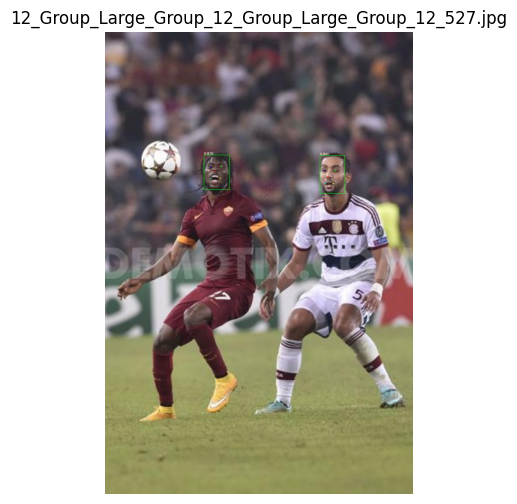

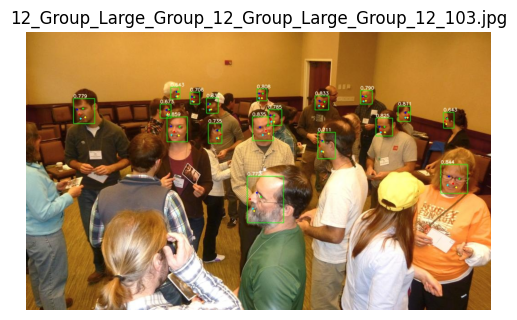

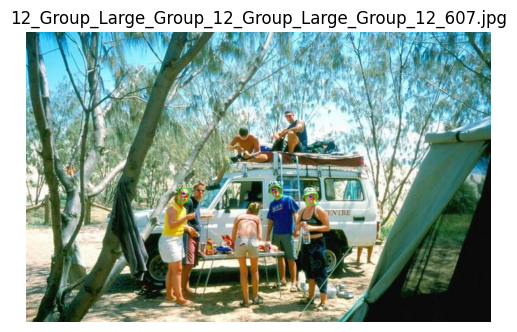

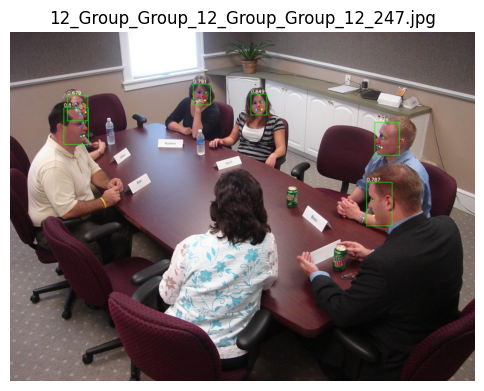

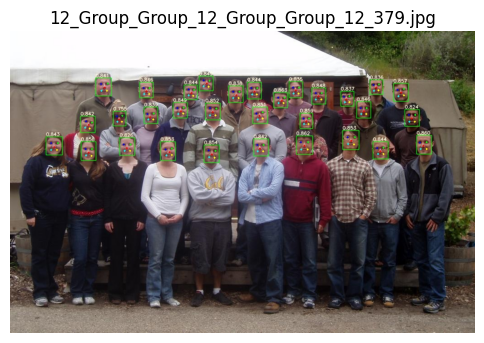

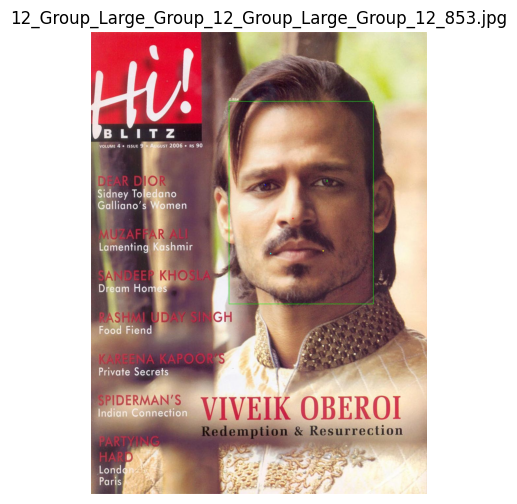

ValueError: invalid literal for int() with base 10: '0--Parade/0_Parade_Parade_0_630.jpg'